<a href="https://colab.research.google.com/github/carlosprr29/ai-progetto-spagnoli/blob/main/notebooks/01_1_Exploratory_Data_Analysis_WELFake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =================================================================
# PHASE: Exploratory Data Analysis (EDA) - WELFake Dataset
# =================================================================

# 1. INSTALLATION AND LOADING OF LIBRARIES
# -----------------------------------------------------------------
# We install datasets in case it's not in the environment
!git clone https://github.com/carlosprr29/ai-progetto-spagnoli.git
%cd ai-progetto-spagnoli
!pip install -r requirements.txt

import sys
import warnings
from google.colab import drive
drive.mount('/content/drive')

# Add the project path to find 'src'
PROJECT_PATH = '/content/drive/MyDrive/Project_IA'
sys.path.append(PROJECT_PATH)

# Import the specific functions from our data_loader.py
from src.data_loader import load_and_clean_welfake
from src.eda_utils import plot_class_balance, generate_cloud, analyse_term, plot_text_length

warnings.filterwarnings('ignore')

In [ ]:
# 2. LOADING THE DATASET FROM HUGGING FACE
# -----------------------------------------------------------------
df = load_and_clean_welfake()

In [ ]:
# 3. CLASS BALANCE ANALYSIS (Bar chart)
# -----------------------------------------------------------------
plot_class_balance(df)

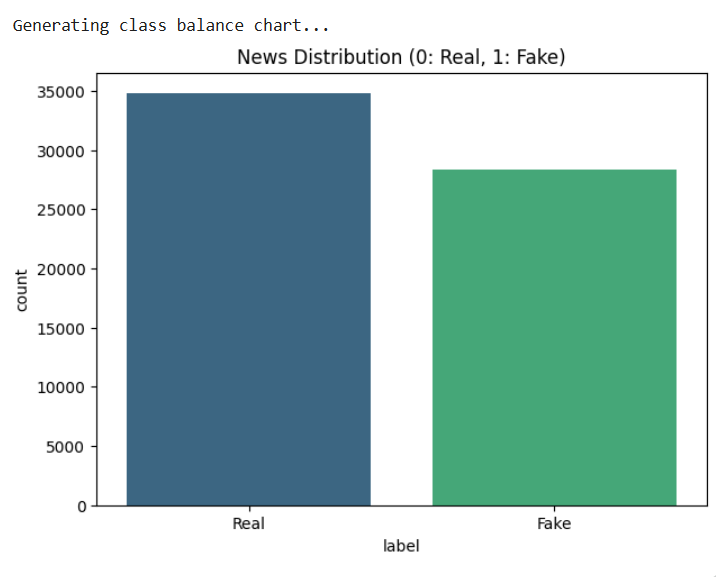

In [ ]:
# 4. CONTENT EXPLORATION (Sampling)
# -----------------------------------------------------------------
print("\n Displaying 50 random news items from the dataset:")
display(df[['title', 'label']].sample(50))

|index|title|label|
|---|---|---|
|37054|bullets and burns: portraits of injured rohingya refugees|0|
|46739|the best tv shows of 2016 - the new york times|0|
|51297|exclusive - hate the tweets, love the agenda: mcconnell on trump|0|
|71556|brazil's meirelles jokes about a vice presidential candidacy|0|
|40358|trump open to dreamers relief legislation without wall funding -aide|0|
|71640|china gets an early win off trump, but many battles remain|0|
|50921|the ladies of ‘the view’ call trump exactly what he is, and he’ll hate it \(video\)|1|
|8575|msnbc “analyst” shocks host when he makes outrageous claim about jared kushner: “that’s a major allegation\. i mean that’s kind of a stretch” \[video\]|1|
|10341|busted\! pro-trump pac rep admits to voter suppression campaign targeting blacks, suburban mothers|1|
|9546|when obama admin went after banks, it forced them to give big money to some\.\.\.questionable groups|1|
|33669|could mcmullin throw the presidential race into the house?|1|
|28003|gop lawmaker blames obama for staging racist mayhem in charlottesville|1|
|58846|nra ‘good guy with a gun’ angry about obama’s executive orders shoots up apartment building \(video\)|1|
|56697|“peaceful” muslims scream: “this is for allah” after driving van 50 mph pedestrians…3 armed terrorists on run in gun-free london…britain’s pm calls it “potential act of terror” \[video\]|1|
|63619|no title|1|
|51268|can trump save america like putin saved russia? — the saker|1|
|67816|obama’s race war backfires: shocking number of students chose not to attend u of missouri after black lives matter tantrums|1|
|20818|social media awash with anti-semitism, new post up every 83 seconds|0|
|22528|goodbye hillary? here comes dumb and dumber|1|
|36507|detroit: bikers show up in big numbers to defend kid rock against leftist protesters \[video\]|1|
|40842|iraqi forces complete kirkuk province takeover after clashes with kurds|0|
|51883|15 tv shows to watch this season - the new york times|0|
|63945|u\.s\. house intelligence committee has 'successful' russia hearing|0|
|46865|former us labor secretary has dire warning: trump is trying to start a civil war|1|
|26743|students sent home from school for wearing traditional swiss clothing considered “racist”|1|
|44663|top u\.s\. intelligence democrat blasts white house over nunes documents|0|
|4126|chart of the day: miami condo market—–choking on inventory, again\!|1|
|51179|house speaker: house ethics watchdog will remain independent|0|
|36934|fox host jeanine pirro: fbi ‘disgraces and politicizes’ itself with ‘wrong’ letter about hillary emails \(video\)|1|
|23968|new york times stands by trump story, rebuts claim of libel|0|
|35282|virginia governor signs gun law compromise measures|0|
|54073|president trump to travel to promote tax overhaul legislation|0|
|45033|kim jong un and north korean media enthusiastically want trump to become president|1|
|34099|officer’s murder trial in freddie gray death turns on ‘rough ride’ - the new york times|0|
|35212|assange: hillary thought libya would be her stepping stone to the presidency|1|
|46321|h-1b experts on trump’s order: ‘this is what we elected him for’|0|
|6046|doctors can lie to pregnant women if this republican gets his way; already passed committee|1|
|2921|mccain proposes $7\.5  billion of new u\.s\. military funding for asia-pacific|0|
|6688|obama tries to reassure latin america about a future with donald trump - the new york times|0|
|62164|funny\! snl’s solution to democrat election denial: “safe space for everyone” \[video\]|1|
|22560|buzz aldrin: we were ordered away from the moon|1|
|46437|french minister calls out trump on climate change as irma wreaks havoc|0|
|62891|kkk leader brags that white supremacists have taken over the republican party \(audio\)|1|
|11050|disgusting video emerges of liberal actor, and democrat donor, ben affleck that should have ended his career|1|
|14006|white house: castro's death will not likely slow u\.s\. efforts toward cuba|0|
|45168|fbi actually did bug trump towers while obama was president|1|
|1792|russia's lavrov says russia committed to iraq territorial integrity: ria|0|
|27015|shallow 5\.4 magnitude earthquake rattles central italy; shakes buildings in rome|1|
|11528|trump supporter who sucker punched black protester: ‘next time, we might have to kill him’ \(video\)|1|

The table shows that our cleaning process was successful. We removed specific names of news agencies (like "Reuters" or "The New York Times") and replaced them with generic terms like "the news outlet." By doing this, we make sure the AI model learns to detect fake news by analyzing the meaning of the words and the writing style, rather than just memorizing the name of the newspaper. This makes our model more fair, honest, and professional.

In [ ]:
# 5. TITLE LENGTH ANALYSIS
# ----------------------------------------------------------------
plot_text_length(df)

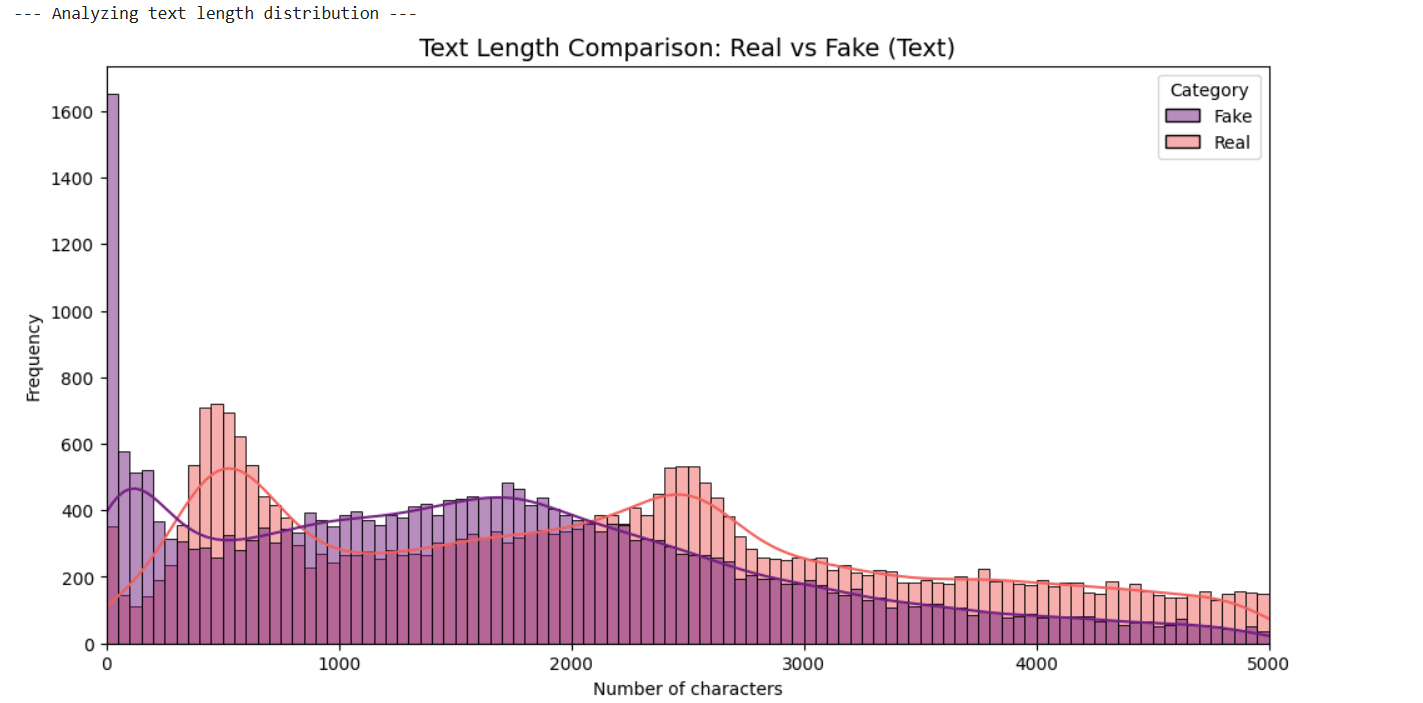

In [ ]:
# 6. WORD CLOUD GENERATION (Term visualisation)
# -----------------------------------------------------------------
generate_cloud(df,
               news_label=0,
               text_col='title',
               colour_map='Greens',
               graph_title='Most common words in REAL headlines')

generate_cloud(df,
               news_label=1,
               text_col='title',
               colour_map='Reds',
               graph_title='Most common words in FAKE headlines')

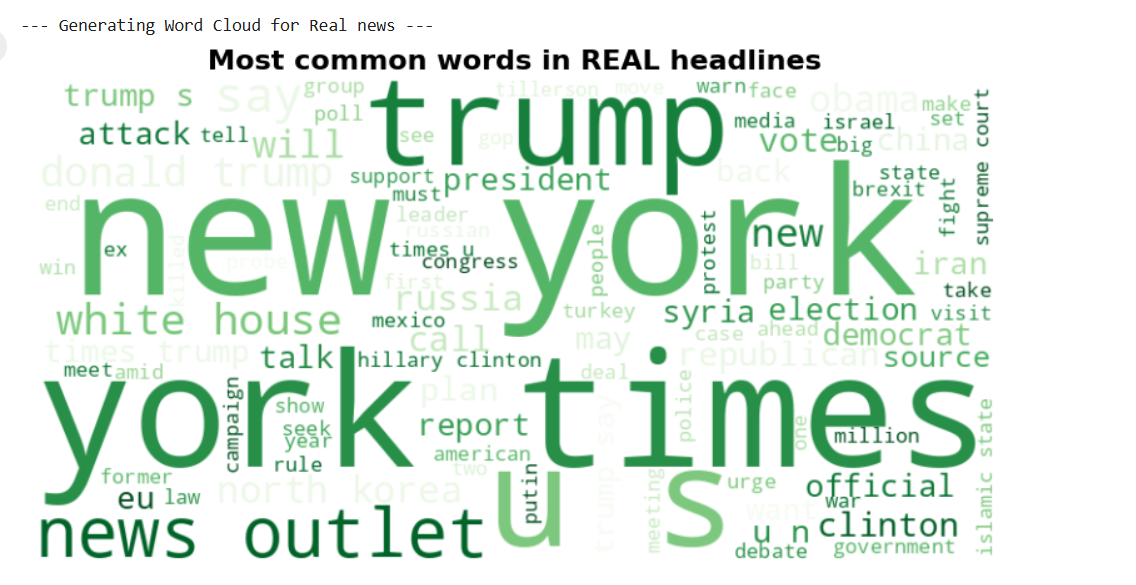

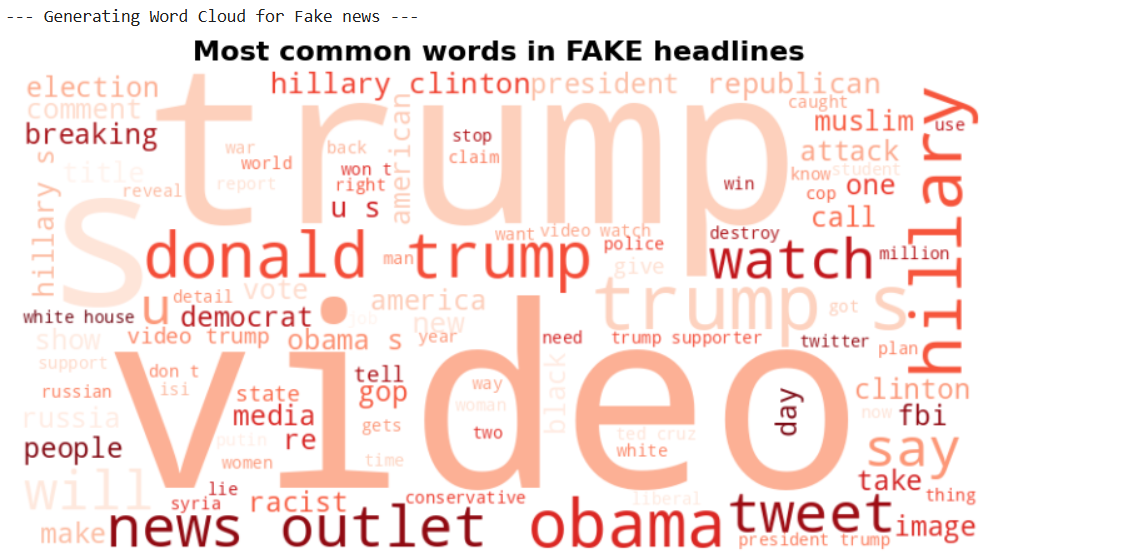

Word cloud analysis reveals a critical lexical divergence between the two classes. While real news is strongly linked to specific newspaper names (NYT), fake news is characterized by the use of sensationalist format tags like 'VIDEO' or 'WATCH'.

This uneven distribution of terms generates a vocabulary bias: the BERT-based model, having limited semantic capacity for this volume of data, opts to classify based on the presence of these high-impact 'tokens'. This explains why the system could fails to classify modern real news stories that employ multimedia formats or satirical news stories that perfectly mimic the institutional lexicon of real sources but with implausible content.

In [ ]:
# 7. SPECIFIC KEYWORD SEARCH ENGINE
# -----------------------------------------------------------------
analyse_term(df, "Trump")
analyse_term(df, "new york")
analyse_term(df, "york times")
analyse_term(df, "VIDEO")
analyse_term(df, "watch")
analyse_term(df, "hillary")
analyse_term(df, "obama")

Term 'Trump' found in 17426 titles.
   ↳ Distribution: {'Fake': '51.65%', 'True': '48.35%'}

Term 'new york' found in 6510 titles.
   ↳ Distribution: {'True': '98.23%', 'Fake': '1.77%'}

Term 'york times' found in 6306 titles.
   ↳ Distribution: {'True': '99.22%', 'Fake': '0.78%'}

Term 'VIDEO' found in 799 titles.
   ↳ Distribution: {'Fake': '82.85%', 'True': '17.15%'}

Term 'watch' found in 1953 titles.
   ↳ Distribution: {'Fake': '87.76%', 'True': '12.24%'}

Term 'hillary' found in 3068 titles.
   ↳ Distribution: {'Fake': '85.04%', 'True': '14.96%'}

Term 'obama' found in 3802 titles.
   ↳ Distribution: {'Fake': '57.60%', 'True': '42.40%'}

#Conclusion
The EDA reveals clear linguistic markers for misinformation. Keywords like 'VIDEO' and 'Watch' are overwhelmingly associated with Fake News (over 87%), indicating a high prevalence of clickbait strategies. Conversely, the mention of established media brands like 'York Times' acts as a strong predictor for Real News (99.2%), highlighting the necessity of our de-biasing process to ensure the model learns semantic patterns rather than just source names.